# Operadores Matematicos

In [1]:
x = 15 + 1.3

print(x)

16.3


In [2]:
x = 40
y = 12

add = x + y
sub = x - y
pro = x * y
div = x / y

print(add)
print(sub)
print(pro)
print(div)

52
28
480
3.3333333333333335


In [3]:
a = 13
b = 12.0

c = a + int(b)
print(c)

25


In [4]:
a = 13
b = 5

c = a / b
print(c)

2.6


# Desafio generico

# Lectura de informacion

Los datos se encuentran en la siguiente link:
[Data Acciones](https://raw.githubusercontent.com/JJTorresDS/stocks-ds-edu/main/stocks.csv)



In [5]:
import pandas as pd

url = 'https://raw.githubusercontent.com/JJTorresDS/stocks-ds-edu/main/stocks.csv'
df = pd.read_csv(url, index_col=0)
print(df.head(5))

                       MCD       SBUX        GOOG        AMZN       MSFT  \
formatted_date                                                             
2016-01-01      106.332146  54.353962  742.950012  587.000000  49.853489   
2016-02-01      100.671043  52.064243  697.770020  552.520020  46.043667   
2016-03-01      108.782211  53.571442  744.950012  593.640015  50.339031   
2016-04-01      109.483307  50.457645  693.010010  659.590027  45.453705   
2016-05-01      105.648926  49.255203  735.719971  722.789978  48.306515   

                      JPM        BAC          C        MAR        HLT  \
formatted_date                                                          
2016-01-01      50.424938  12.573010  36.897804  57.754189  35.192841   
2016-02-01      48.033066  11.132540  33.707108  64.228912  41.061607   
2016-03-01      50.524323  12.021718  36.223217  67.336624  44.499886   
2016-04-01      53.919910  12.995729  40.153545  66.305466  43.716049   
2016-05-01      56.098225  13

In [6]:
df.head()

,MCD,SBUX,GOOG,AMZN,MSFT,JPM,BAC,C,MAR,HLT,RCL,V,MA,PYPL
formatted_date,,,,,,,,,,,,,,
2016-01-01,106.332146,54.353962,742.950012,587.000000,49.853489,50.424938,12.573010,36.897804,57.754189,35.192841,74.235298,71.574371,85.822624,36.139999
2016-02-01,100.671043,52.064243,697.770020,552.520020,46.043667,48.033066,11.132540,33.707108,64.228912,41.061607,67.360649,69.556580,83.956566,38.139999
2016-03-01,108.782211,53.571442,744.950012,593.640015,50.339031,50.524323,12.021718,36.223217,67.336624,44.499886,74.790009,73.631477,91.278160,38.599998
2016-04-01,109.483307,50.457645,693.010010,659.590027,45.453705,53.919910,12.995729,40.153545,66.305466,43.716049,70.465584,74.363144,93.683258,39.180000
2016-05-01,105.648926,49.255203,735.719971,722.789978,48.306515,56.098225,13.201019,40.447887,62.474155,41.198154,70.456474,75.999847,92.817329,37.790001


Miremos el tamaño de nuestro datraframe

In [7]:
df.shape

(71, 14)

11 filas x 14 columnas

Las columnas son los precios de acciones de:

1. MCD: Macdonals
2. SBUX: Starbucks
3. GOOG: Google
4. AMZN: Amazon
5. MSFT: Microsoft
6. JPM: JPMorgan Chase & Co.
7. BAC: Bank of America Corp
8. C: Citigroup
9. MAR: Pharma MAr
10. HLT: Hoteles Hilton
11. RCL: Royal Caribbean Cruises
12. V: Visa Inc.
13. MA: Mastercard
14. PYPL: Paypal

# Parte 1

# Analizando el comportamiento de una serie de tiempo

<Axes: title={'center': 'Precio Accion vs Fecha'}, xlabel='Fecha', ylabel='Precio Accion'>

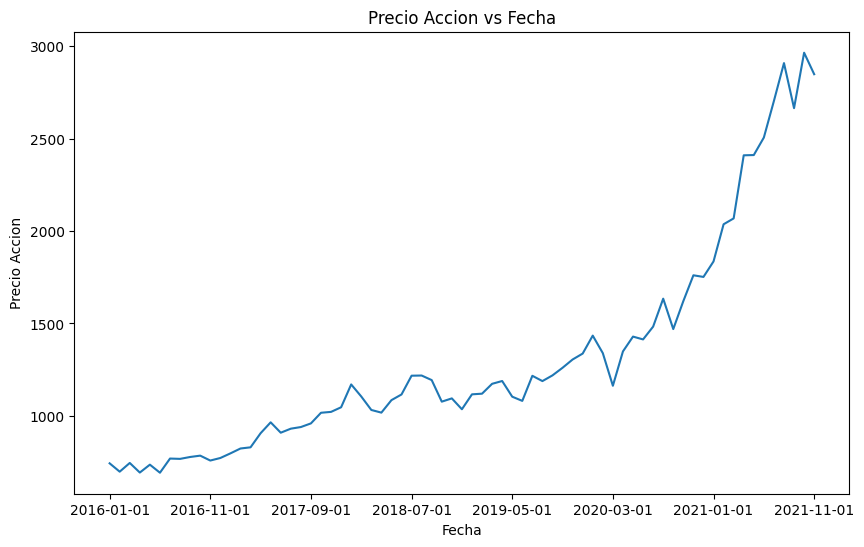

In [8]:
df['GOOG'].plot(kind='line',figsize=(10,6),xlabel='Fecha', ylabel='Precio Accion', title='Precio Accion vs Fecha')

Se observa un comportamiento creciente entre el 01/01/21 hasta el 11/01/2021

# Extraccion usando indices booleanos

In [9]:
columnas=list(df.columns)

google= [x for x in columnas if x =='GOOG']
google

['GOOG']

In [10]:
indice_col=list(df.columns=='GOOG')
df_goog=df.loc[:,indice_col]
df_goog # Hemos terminado

,GOOG
formatted_date,
2016-01-01,742.950012
2016-02-01,697.770020
2016-03-01,744.950012
2016-04-01,693.010010
2016-05-01,735.719971
...,...
2021-07-01,2704.419922
2021-08-01,2909.239990
2021-09-01,2665.310059


# Grafico interactivo



In [11]:
df_n= df_goog.copy()
df_n['Fecha']= df_n.index
df_n= df_n.reset_index(drop=True)
df_n['Fecha']=pd.to_datetime(df_n['Fecha'])
df_n

,GOOG,Fecha
0,742.950012,2016-01-01
1,697.770020,2016-02-01
2,744.950012,2016-03-01
3,693.010010,2016-04-01
4,735.719971,2016-05-01
...,...,...
66,2704.419922,2021-07-01
67,2909.239990,2021-08-01
68,2665.310059,2021-09-01
69,2965.409912,2021-10-01


In [12]:
import plotly.express as px


fig=px.line(data_frame=df_n,x='Fecha',y='GOOG',title='Comportamiento GOOGLE',\
             labels={
                     "Fecha": "Fecha_dias",
                     "value": "Precio (USD)"
                 })
fig.update_layout(paper_bgcolor="#FFFFFF",plot_bgcolor='#FFFFFF',)

fig.show()

# Parte 2

In [13]:
df_n

,GOOG,Fecha
0,742.950012,2016-01-01
1,697.770020,2016-02-01
2,744.950012,2016-03-01
3,693.010010,2016-04-01
4,735.719971,2016-05-01
...,...,...
66,2704.419922,2021-07-01
67,2909.239990,2021-08-01
68,2665.310059,2021-09-01
69,2965.409912,2021-10-01


In [14]:
pasos = 2
def my_fun(x):
    return x.iloc[-1] - x.iloc[0]

df_n['Dif']=df_n['GOOG'].rolling(window=pasos).apply(my_fun) # Hacemos la diferencia del valor actual - anterior
df_n

,GOOG,Fecha,Dif
0,742.950012,2016-01-01,NaN
1,697.770020,2016-02-01,-45.179993
2,744.950012,2016-03-01,47.179993
3,693.010010,2016-04-01,-51.940002
4,735.719971,2016-05-01,42.709961
...,...,...,...
66,2704.419922,2021-07-01,198.099854
67,2909.239990,2021-08-01,204.820068
68,2665.310059,2021-09-01,-243.929932
69,2965.409912,2021-10-01,300.099854


In [15]:
# HAcemos un filtro de cuando los valores de Dif <0
index_bool= df_n.Dif<0
index_bool

,Dif
0,False
1,True
2,False
3,True
4,False
...,...
66,False
67,False
68,True
69,False


In [16]:
# Ahora podemos aplicar el filtro sobre el objeto data frame
df_neg=df_n.loc[index_bool,:]
df_neg

,GOOG,Fecha,Dif
1,697.770020,2016-02-01,-45.179993
3,693.010010,2016-04-01,-51.940002
5,692.099976,2016-06-01,-43.619995
7,767.049988,2016-08-01,-1.739990
10,758.039978,2016-11-01,-26.500000
17,908.729980,2017-06-01,-56.130005
25,1104.729980,2018-02-01,-65.209961
26,1031.790039,2018-03-01,-72.939941
27,1017.330017,2018-04-01,-14.460022
32,1193.469971,2018-09-01,-24.719971


Solo existieron dos días donde la accion bajo de precio

# Graficando fechas donde ocurrio la bajada

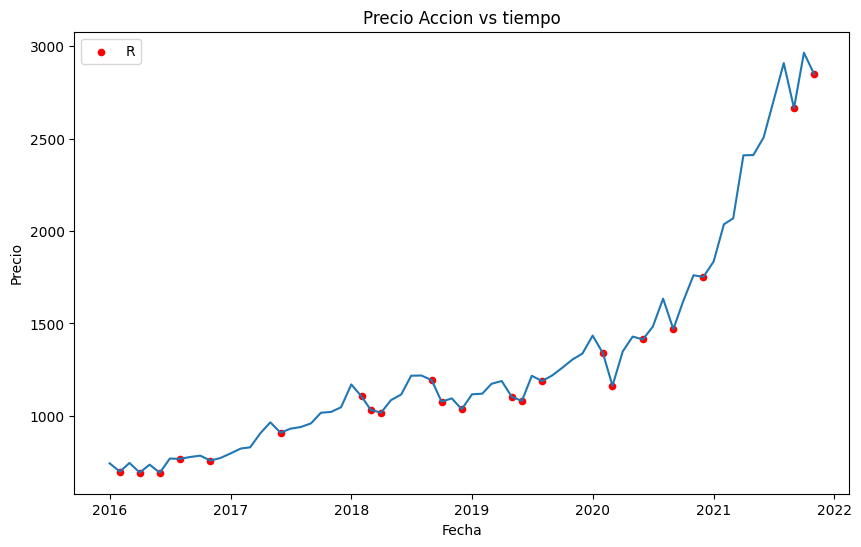

In [17]:
import matplotlib.pyplot as plt
fig,ax= plt.subplots(figsize=(10,6))
ax.plot(df_n.Fecha,df_n.GOOG)
ax.scatter(x=df_neg.Fecha, y= df_neg.GOOG, s=20, color='red', label='R')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio')
ax.set_title('Precio Accion vs tiempo')
ax.legend(loc='upper left')

# Desafio

Intenten hacer le mismo procedimiento para AMZN y observen si existe el mismo patron

Con esto entonces podemos monitorear cuando una accion puede disminuir su valor